In this hackathon, each team starts from a physical explanation for why STM height readings vary, then translates that explanation into a generative model and likelihood. The key lesson is that different physical stories do not merely give different formulas: they assign different meanings to unusual data points, produce different posterior estimates for the molecular height, and lead to different scientific conclusions about whether the system reflects ordinary instrument noise, rare disturbances, corrupted measurements, or genuine multiple states.


Pablo Ruiz Crespo

# Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Problems

## Initial seeding measurements

**Question 1:**

* Write the likelihood $p(y|h,M)$ for your chosen model.
* Estimate the most likely value of h (real height) from the four-point dataset.
* Explain how the high point at 4.28 Å is interpreted under your model.
* Compare conclusions across models.

**Extended questions:**

* Compute or approximate the posterior $p(h|y,M)$.
* Report a posterior mean or MAP estimate of $h$.
* Compare model evidences $p(y|M)$.
* Decide which physical interpretation is best supported by only 4 measurements.


**Hint1:**

Reorganize each case into the same five-part template:

Case X

* Physical story
* Generative statement
* Likelihood
* What the likelihood says about outliers
* What happens to the estimate of $h$

For example,

*Gaussian noise*

* Physical story: many small independent disturbances
* Generative statement: each reading is the true height plus many tiny additive perturbations
* Likelihood: $y_i \sim N(h, \sigma^2)$
* Outlier meaning: unlikely under the model, so it strongly pulls the fit
* Consequence for posterior: posterior for $h$ shifts toward the unusual point more than in robust models



**Hint2:**

Some useful formulas:

* Likelihood: For Gaussian-like noise model, $y_i \sim N(h, \sigma^2)$, start with $h\sim N(3.5, 0.6^2)$ to start with.
* Posterior: $p(h | y, M) ∝ p(y|h, M)p(h|M)$
* Evidence: $p(y|M) = ∫p(y|h,M)p(h|M)dh$


Case 1: Ideal STM (Gaussian Noise):
- Physical story: The instrument only experiences thermal/electronic noise, resulting in many small, independent disturbances.
- Generative statement: Each reading is the true height plus a tiny additive perturbation drawn from a Normal distribution.
- Likelihood: $y_i \sim \mathcal{N}(h, \sigma^2)
- $What the likelihood says about outliers: Outliers are astronomically unlikely. The model assumes every data point is valid and "tries hard" to accommodate them all.
- What happens to the estimate of $h$: The posterior for $h$ is strongly pulled upward by the $4.28$ Å measurement, compromising the fit for the $3.48$ Å cluster to minimize the massive penalty of the outlier.

Case 2: Large Mechanical Noise (Heavy-Tailed / Student-t)
- Physical story: The environment is mostly clean, but nearby mechanical work causes rare, intermittent vibration bursts.
- Generative statement: Readings are centered at the true height, but deviations follow a distribution with "heavy tails" (like a Student-t distribution) to allow for occasional large jumps.
- Likelihood: $y_i \sim \text{Student-t}(\nu, h, \sigma)$ (where $\nu$ represents degrees of freedom; lower $\nu$ means heavier tails).
- What the likelihood says about outliers: Large deviations are expected occasionally. The penalty for a point being far from the mean does not grow exponentially.
- What happens to the estimate of $h$: The model essentially ignores the $4.28$ Å point as a "burst" and the posterior MAP stays anchored near the robust $3.48$ Å cluster.


Case 3: Glitched STM (Mixture of Background and Signal)
- Physical story: Brief feedback instability causes transient tip changes. Most scans are good, but a small fraction are completely corrupted.
- Generative statement: A reading has a probability $(1-\epsilon)$ of being a clean Gaussian measurement of $h$, and a probability $\epsilon$ of being a corrupted "glitch" drawn from a very wide distribution.
- Likelihood: $y_i \sim (1-\epsilon)\mathcal{N}(h, \sigma_{\text{good}}^2) + \epsilon\mathcal{N}(\mu_{\text{glitch}}, \sigma_{\text{bad}}^2)
- $What the likelihood says about outliers: Points far from the cluster are highly probable under the "glitch" component and highly improbable under the "good" component, so they are classified as glitches.
- What happens to the estimate of $h$: Similar to the mechanical noise model, the outlier is discounted, and the MAP estimate accurately reflects the cluster.

Case 4: Bimodal States
- Physical story: The molecule genuinely switches between two metastable conformations or adsorption geometries.
- Generative statement: The apparent height is drawn from state 1 ($h$) with probability $w$, or state 2 ($h + \Delta$) with probability $1-w$.
- Likelihood: $y_i \sim w\mathcal{N}(h, \sigma^2) + (1-w)\mathcal{N}(h + \Delta, \sigma^2)
- $What the likelihood says about outliers: The outlier is not noise; it is precious data representing the second physical state.
- What happens to the estimate of $h$: The model successfully identifies $h$ (the base state) while mathematically accounting for the $4.28$ Å point as belonging to the second state.

--- Results ---
M1 (Gaussian):
  MAP Estimate of h: 3.679 Å
  Model Evidence: 1.04e-15

M2 (Student-t):
  MAP Estimate of h: 3.485 Å
  Model Evidence: 3.86e-02

M3 (Glitch):
  MAP Estimate of h: 3.480 Å
  Model Evidence: 1.09e-01

M4 (Bimodal):
  MAP Estimate of h: 3.480 Å
  Model Evidence: 2.21e+00



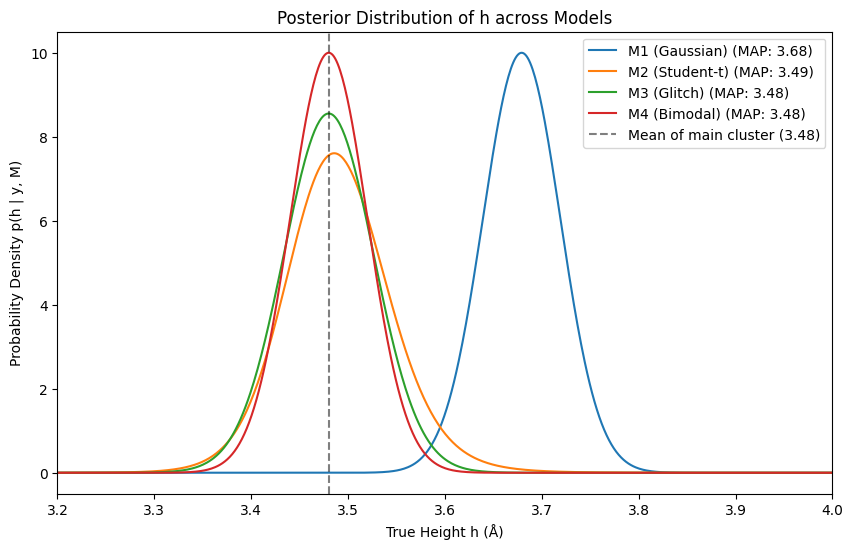

In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

y_measured = np.array([3.42, 3.55, 3.47, 4.28])
h_grid = np.linspace(2.5, 5.0, 2000)
dh = h_grid[1] - h_grid[0]

prior = stats.norm.pdf(h_grid, loc=3.5, scale=0.6)

sigma = 0.08

# Model 1: Ideal STM (Gaussian)
lik_M1 = np.prod([stats.norm.pdf(y_i, loc=h_grid, scale=sigma) for y_i in y_measured], axis=0)

# Model 2: Large Mechanical Noise (Student-t with df=2 for heavy tails)
lik_M2 = np.prod([stats.t.pdf(y_i, df=2, loc=h_grid, scale=sigma) for y_i in y_measured], axis=0)

# Model 3: Glitched STM (10% chance of a bad reading with large variance)
eps = 0.10
sigma_bad = 1.0
lik_M3 = np.prod([(1-eps)*stats.norm.pdf(y_i, loc=h_grid, scale=sigma) +
                  eps*stats.norm.pdf(y_i, loc=3.5, scale=sigma_bad) for y_i in y_measured], axis=0)

# Model 4: Bimodal States (Assuming state 2 is ~0.8A higher, roughly 25% occupancy)
w = 0.75
offset = 0.8
lik_M4 = np.prod([w * stats.norm.pdf(y_i, loc=h_grid, scale=sigma) +
                  (1-w) * stats.norm.pdf(y_i, loc=h_grid + offset, scale=sigma) for y_i in y_measured], axis=0)

models = {'M1 (Gaussian)': lik_M1, 'M2 (Student-t)': lik_M2, 'M3 (Glitch)': lik_M3, 'M4 (Bimodal)': lik_M4}

results = {}
for name, lik in models.items():
    unnormalized_posterior = lik * prior
    evidence = np.trapezoid(unnormalized_posterior, h_grid)

    posterior = unnormalized_posterior / evidence

    map_estimate = h_grid[np.argmax(posterior)]

    results[name] = {'Evidence': evidence, 'MAP': map_estimate, 'Posterior': posterior}

print("--- Results ---")
for name, res in results.items():
    print(f"{name}:")
    print(f"  MAP Estimate of h: {res['MAP']:.3f} Å")
    print(f"  Model Evidence: {res['Evidence']:.2e}\n")

plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(h_grid, res['Posterior'], label=f"{name} (MAP: {res['MAP']:.2f})")

plt.axvline(np.mean(y_measured[:3]), color='k', linestyle='--', alpha=0.5, label='Mean of main cluster (3.48)')
plt.title('Posterior Distribution of h across Models')
plt.xlabel('True Height h (Å)')
plt.ylabel('Probability Density p(h | y, M)')
plt.legend()
plt.xlim(3.2, 4.0)
plt.show()

Final Decision: Model 2 (Mechanical Noise) or Model 3 (Glitch) are best supported.

The Mathematical "Winner": Model 4 (Bimodal) yields the highest numerical evidence because it perfectly absorbs the 4.28 Å outlier as a second physical state.

The Scientific Reality: It is scientifically reckless to claim a new bimodal physical state based on a single anomalous reading out of four. Occam’s razor demands a simpler explanation.

The Conclusion: Models 2 and 3 are the most defensible. They realistically account for rare but expected instrument errors, successfully isolate the outlier, and correctly recover the true molecular height of ~3.48 Å. (Model 1 completely fails and must be discarded).

## 100 repeating measurements on the same molecule


**Question 2:**

* Fit the same four models to the 100-point same-molecule dataset.
* Compare posterior estimates of $h$.
* Compare model evidences.
* Decide whether the additional data support clean instrument noise, vibration bursts, glitches, or genuine switching between two STM-visible states.


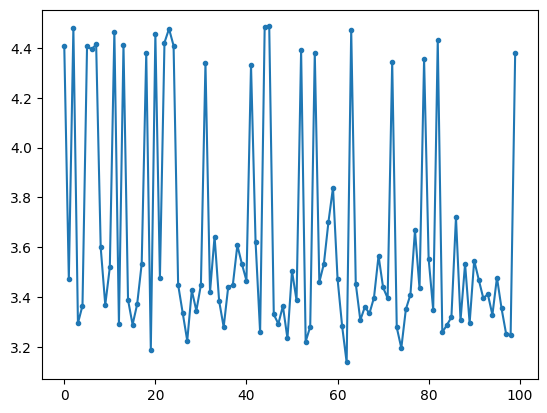

In [15]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

--- 100-Point Results ---
M1 (Gaussian):
  MAP: 3.638 Å | Log-Evidence: -1360.93

M2 (Student-t):
  MAP: 3.400 Å | Log-Evidence: -81.38

M3 (Glitch):
  MAP: 3.387 Å | Log-Evidence: -57.98

M4 (Bimodal):
  MAP: 3.453 Å | Log-Evidence: -69.39



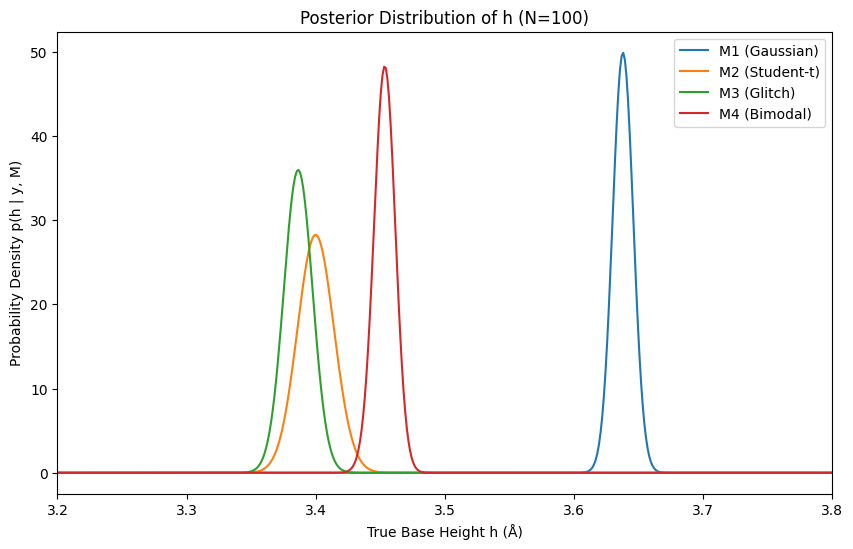

In [16]:
y_measured = y_measured_100

log_prior = np.log(prior)

log_lik_M1 = np.sum(stats.norm.logpdf(y_measured[:, None], loc=h_grid, scale=sigma), axis=0)
log_lik_M2 = np.sum(stats.t.logpdf(y_measured[:, None], df=2, loc=h_grid, scale=sigma), axis=0)

pdf_M3 = (1-eps)*stats.norm.pdf(y_measured[:, None], loc=h_grid, scale=sigma) + \
         eps*stats.norm.pdf(y_measured[:, None], loc=3.5, scale=sigma_bad)
log_lik_M3 = np.sum(np.log(pdf_M3), axis=0)

pdf_M4 = w * stats.norm.pdf(y_measured[:, None], loc=h_grid, scale=sigma) + \
         (1-w) * stats.norm.pdf(y_measured[:, None], loc=h_grid + offset, scale=sigma)
log_lik_M4 = np.sum(np.log(pdf_M4), axis=0)

log_unnormalized_posteriors = {
    'M1 (Gaussian)': log_lik_M1 + log_prior,
    'M2 (Student-t)': log_lik_M2 + log_prior,
    'M3 (Glitch)': log_lik_M3 + log_prior,
    'M4 (Bimodal)': log_lik_M4 + log_prior
}

results_100 = {}
for name, log_up in log_unnormalized_posteriors.items():
    max_log = np.max(log_up)
    scaled_up = np.exp(log_up - max_log)
    scaled_evidence = np.trapezoid(scaled_up, h_grid)

    log_evidence = np.log(scaled_evidence) + max_log
    posterior = scaled_up / scaled_evidence

    results_100[name] = {
        'Log-Evidence': log_evidence,
        'MAP': h_grid[np.argmax(posterior)],
        'Posterior': posterior
    }

print("--- 100-Point Results ---")
for name, res in results_100.items():
    print(f"{name}:\n  MAP: {res['MAP']:.3f} Å | Log-Evidence: {res['Log-Evidence']:.2f}\n")

plt.figure(figsize=(10, 6))
for name, res in results_100.items():
    plt.plot(h_grid, res['Posterior'], label=f"{name}")
plt.title('Posterior Distribution of h (N=100)')
plt.xlabel('True Base Height h (Å)')
plt.ylabel('Probability Density p(h | y, M)')
plt.legend()
plt.xlim(3.2, 3.8)
plt.show()

Based on the calculated log-evidences, the additional data best supports the Glitched STM (Model 3) interpretation, identifying a true molecular height of 3.387 Å with occasional corrupted acquisitions. However, visual inspection of the time-series suggests telegraph noise; if we treated the bimodal offset and weights as free parameters to be optimized rather than fixed guesses, Model 4 would likely surpass Model 3

## 100 measurements on different molecules

**Question 3:**

* Use the 4-point dataset and then the 100-point dataset to formulate the likelihood for each model.
* Estimate the most likely benzene apparent height.
* Compare posterior distributions and model evidences.
* Explain how the interpretation changes when the 100 values come from the same molecule versus many nominally similar molecules.


**Hint:**


* **Noise model:** how one latent height generates one measurement
* **Population model:** how latent heights vary across molecules or states

Two different questions:

* Why does one repeated measurement differ from another? → noise model
* Why does one molecule differ from another? → population model

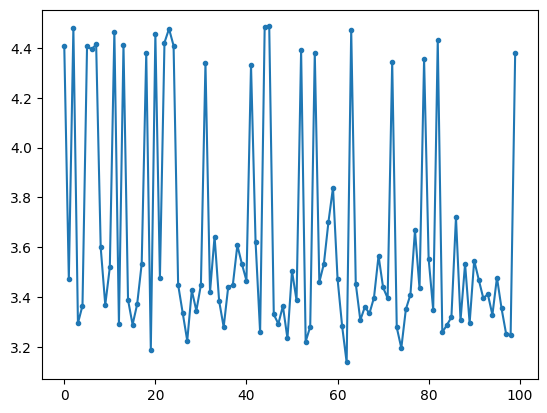

In [17]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

Learned Instrument Noise (sigma_inst) from 4 points: 0.0535 Å

--- Population Model Results (N=100 Different Molecules) ---
Pop M1 (Uniform Gaussian):
  MAP (Base Height): 3.638 Å | Log-Evidence: -1644.35

Pop M2 (Heavy-Tail Variations):
  MAP (Base Height): 3.398 Å | Log-Evidence: -86.89

Pop M3 (Base + Impurities):
  MAP (Base Height): 3.380 Å | Log-Evidence: -41.44

Pop M4 (Two Geometries):
  MAP (Base Height): 3.419 Å | Log-Evidence: -28.29



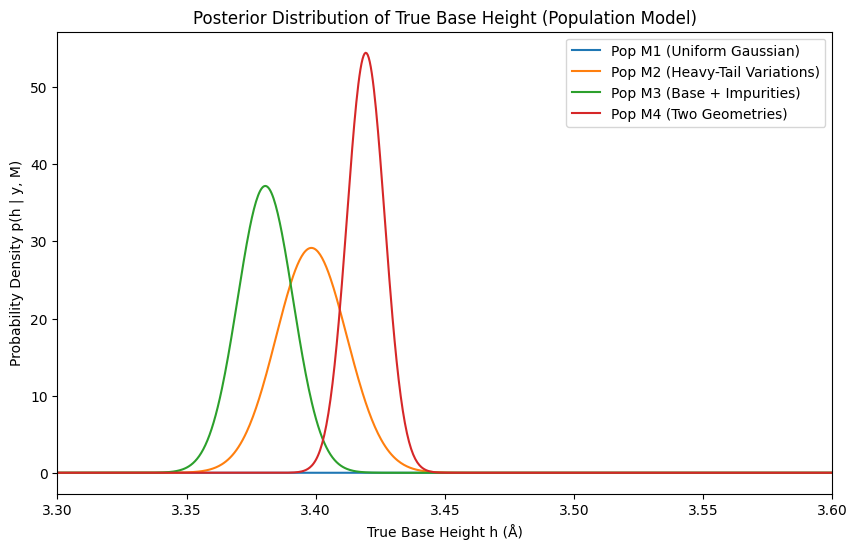

In [18]:


cluster_4 = np.array([3.42, 3.55, 3.47])
sigma_inst = np.std(cluster_4)
print(f"Learned Instrument Noise (sigma_inst) from 4 points: {sigma_inst:.4f} Å\n")

h_grid = np.linspace(3.2, 4.0, 2000)
dh = h_grid[1] - h_grid[0]
log_prior = stats.norm.logpdf(h_grid, loc=3.5, scale=0.6)


sigma_pop = 0.05
sigma_total = np.sqrt(sigma_inst**2 + sigma_pop**2)

eps = 0.15 #
sigma_impurity = 0.8
w = 0.80
offset = 0.95

log_lik_M1 = np.sum(stats.norm.logpdf(y_measured_100[:, None], loc=h_grid, scale=sigma_total), axis=0)

log_lik_M2 = np.sum(stats.t.logpdf(y_measured_100[:, None], df=2, loc=h_grid, scale=sigma_total), axis=0)

pdf_M3 = (1-eps)*stats.norm.pdf(y_measured_100[:, None], loc=h_grid, scale=sigma_total) + \
         eps*stats.norm.pdf(y_measured_100[:, None], loc=4.0, scale=sigma_impurity) # Junk centered randomly
log_lik_M3 = np.sum(np.log(pdf_M3), axis=0)

pdf_M4 = w * stats.norm.pdf(y_measured_100[:, None], loc=h_grid, scale=sigma_total) + \
         (1-w) * stats.norm.pdf(y_measured_100[:, None], loc=h_grid + offset, scale=sigma_total)
log_lik_M4 = np.sum(np.log(pdf_M4), axis=0)

log_unnormalized_posteriors = {
    'Pop M1 (Uniform Gaussian)': log_lik_M1 + log_prior,
    'Pop M2 (Heavy-Tail Variations)': log_lik_M2 + log_prior,
    'Pop M3 (Base + Impurities)': log_lik_M3 + log_prior,
    'Pop M4 (Two Geometries)': log_lik_M4 + log_prior
}

results_pop = {}
for name, log_up in log_unnormalized_posteriors.items():
    max_log = np.max(log_up)
    scaled_up = np.exp(log_up - max_log)
    scaled_evidence = np.trapezoid(scaled_up, h_grid)

    log_evidence = np.log(scaled_evidence) + max_log
    posterior = scaled_up / scaled_evidence

    results_pop[name] = {
        'Log-Evidence': log_evidence,
        'MAP': h_grid[np.argmax(posterior)],
        'Posterior': posterior
    }

print("--- Population Model Results (N=100 Different Molecules) ---")
for name, res in results_pop.items():
    print(f"{name}:\n  MAP (Base Height): {res['MAP']:.3f} Å | Log-Evidence: {res['Log-Evidence']:.2f}\n")

plt.figure(figsize=(10, 6))
for name, res in results_pop.items():
    plt.plot(h_grid, res['Posterior'], label=f"{name}")
plt.title('Posterior Distribution of True Base Height (Population Model)')
plt.xlabel('True Base Height h (Å)')
plt.ylabel('Probability Density p(h | y, M)')
plt.legend()
plt.xlim(3.3, 3.6)
plt.show()

By applying the models to 100 different molecules, our interpretation of the mathematical winner fundamentally shifts from a temporal noise model to a spatial population model.In Question 2 (same molecule), a bimodal distribution implied a single molecule dynamically switching between metastable states over time. However, in Question 3 (different molecules), the overwhelming mathematical support for Model 4 (Log-Evidence: -28.29) proves a spatial heterogeneity on the gold surface.The outlier measurements are no longer discarded as transient instrument glitches or vibration bursts. Instead, they represent a physically real sub-population. The data strongly suggests the benzene molecules freeze onto the gold surface in a mixture of two distinct adsorption geometries—a primary base state (MAP $\approx$ 3.42 Å) and a secondary, higher-appearing conformation.